<div class="alert alert-block alert-success">
<b></b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


PROYECTO INTEGRADO
1. Exploracion de datos

In [ ]:
# importar la libreria
import pandas as pd

df=pd.read_csv('/datasets/games.csv')

#revisar estructura del data set
df.info()
print()
print(df.head())
print(df.sample())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08 


observando los datos, se evidencian valores ausentes ausentes en las columnas name, platform, genre,critic score
user score y rating, los cuales vamos a convertir a minusculas los nombres de los todas la columnas del dataset para evitar confusiones en la manipulacion de los datos.

Tambien se observa que la columna year deberia ser de tipo entero y no float 64 y luego redondear a un decimal por tratarse de millones, user score se debe convertir en float 64 y mantener rating como object

Revisar el tratamiento de los valores ausentes en las columnas identificadas
Revisar si hay duplicados
Revisar si existen valores duplicados implicitos en las columnas Name, Platform y  genre


2.PREPARACION DE LOS DATOS
2.1 Conversión de nombres de columnas
2.2 Conversión de tipos de datos
2.3 Tratamiento de valores ausentes y duplicados
2.4 Cálculo de ventas totales

In [ ]:
#convertir nombres de las columnas a minuscula
print(df.columns.tolist())  #no hay espacios en los nombres de las columnas
df.columns=df.columns.str.lower() 
print(df.head())

['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales', 'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating']
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score user_score rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22       

In [ ]:
#Revisar cuantos ausentes hay y convertir a Int64, entero
print(df['year_of_release'].isna().sum()) 
df['year_of_release']=df['year_of_release'].astype('Int64')
df.info()

269
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


Se decidio mantener los datos ausentes porque no se peude alterar informacion real sobre los years del data set, la cantidad de ausentes es muy baja con respecto al total de entradas

In [ ]:
#revisar la columna name y para tratar los ausentes

print(df['name'].isna().sum())
df['name']=df['name'].fillna('Unknown')
print(df[df['name']=='Unknown'])


2
          name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    Unknown      GEN             1993   NaN      1.78      0.53      0.00   
14244  Unknown      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Se decidio llenar los 2 valores ausentes encontrados con Unknown en la columna name por ser un dato categorico que permite el analsis por plataforma/año y asi conservar la informacion a pesar que las filas solo contienen la informacion plataforma, year y ventas

In [ ]:
#revisar la columna genre y para tratar los ausentes

print(df['genre'].isna().sum())
print(df[df['genre'].isna()])



2
          name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    Unknown      GEN             1993   NaN      1.78      0.53      0.00   
14244  Unknown      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  
659           0.08           NaN        NaN    NaN  
14244         0.00           NaN        NaN    NaN  


Al igual que se decidio en el paso anterior, se reviso y se decidio mantiener  sin alteraciones lo valores ausente(corresponden a Unknonw name), por ser un dato categorico que permite el analsis por plataforma/año se conservara la informacion a pesar que las filas solo contienen la informacion plataforma, year y ventas. No se trataran los ausentes se dejaran asi tal cual.

In [ ]:
# Revision de la columna Rating (ESRB)
print(df['rating'].isna().sum())
print(df[df['rating'].isna()])

6766
                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sale

In [ ]:
# Verificar los valores ausentes del dataset para las columnas rating, critic_score y user-score por agrupacion por year

print(df.groupby('year_of_release')['rating'].apply(lambda x: x.isna().sum()))

# Verificar los valores ausentes del dataset en critic_score
print(df.groupby('year_of_release')['critic_score'].apply(lambda x: x.isna().sum()))

# Verificar los valores ausentes del dataset en user_score  
print(df.groupby('year_of_release')['user_score'].apply(lambda x: x.isna().sum()))



year_of_release
1980      9
1981     46
1982     36
1983     17
1984     14
1985     13
1986     21
1987     16
1988     14
1989     17
1990     16
1991     41
1992     41
1993     62
1994    120
1995    219
1996    256
1997    270
1998    347
1999    296
2000    202
2001    143
2002    174
2003    162
2004    164
2005    233
2006    328
2007    376
2008    446
2009    415
2010    456
2011    433
2012    298
2013    228
2014    236
2015    291
2016    222
Name: rating, dtype: int64
year_of_release
1980      9
1981     46
1982     36
1983     17
1984     14
1985     13
1986     21
1987     16
1988     14
1989     17
1990     16
1991     41
1992     42
1993     62
1994    120
1995    219
1996    255
1997    272
1998    351
1999    299
2000    207
2001    156
2002    202
2003    190
2004    201
2005    284
2006    386
2007    505
2008    712
2009    775
2010    755
2011    636
2012    332
2013    271
2014    320
2015    381
2016    270
Name: critic_score, dtype: int64
year_of_release
1980



Observando que aproximandamente el 40 % de los datos de rating son valores ausentes, se decide mantenerlos pero llenarlos como unrate para futuros analisis dado que se puede observar que a medida que aumentan los years, no se cuenta con esta informacion. 

Con respecto al resto de las columnas critic_score y user_score se van a mantener con sus valores ausentes dado que tambien representan un porcentaje considerable de los datos y un comportamiento muy parecido por year a los datos de rating, es probable todos estos datos sean de juegos muy antiguos o muy viejos, o sean de categorias que no estan en estudio,  no se puede alterar la informacion del dataframe rellenando con informacion que no es real.

 

In [ ]:
#Llenar los valores ausentes de rating con 'Unrating'

df['rating']=df['rating'].fillna('Unrated')

# Verificar el cambio
print('Conteo de categorias en rating')
print(df['rating'].value_counts())


Conteo de categorias en rating
Unrated    6766
E          3990
T          2961
M          1563
E10+       1420
EC            8
K-A           3
RP            3
AO            1
Name: rating, dtype: int64


In [ ]:
# Buscar valores TBD en todas las columnas de texto

columnas_texto = df.select_dtypes(include=['object']).columns
print("Columnas de texto:", columnas_texto.tolist())

for columna in columnas_texto:
    tbd_count = df[columna].str.contains('tbd', case=False, na=False).sum()
    if tbd_count > 0:
        print(f"Columna '{columna}': {tbd_count} valores TBD encontrados")



Columnas de texto: ['name', 'platform', 'genre', 'user_score', 'rating']
Columna 'user_score': 2424 valores TBD encontrados


Con respecto a los tbd encontrados considero que no se deben tocar porque es informacion que en el futuro puede registrarse y es mas facil identificar

In [ ]:

#revisar duplicados en nombres
print(df.duplicated().sum())

duplicados = df['name'].value_counts()
nombres_duplicados = duplicados[duplicados > 1]

print(nombres_duplicados)

#revisar el nombre mas duplicado 12 apariciones
juego_ejemplo = "Need for Speed: Most Wanted"
df[df['name'] == "Need for Speed: Most Wanted"][['name', 'platform', 'year_of_release', 'genre']]

#Buscar posibles duplicados implicitos
# Crear una columna con nombres normalizados (todo en minúsculas)
df['name_normalized'] = df['name'].str.lower()

# Comparar cuántos nombres únicos tenemos antes y después de normalizar
print("Nombres únicos originales:", df['name'].nunique())
print("Nombres únicos normalizados:", df['name_normalized'].nunique())
print("Diferencia:", df['name'].nunique() - df['name_normalized'].nunique())

# Verificar espacios extra
df['name_stripped'] = df['name'].str.strip()  # Quitar espacios al inicio/final
df['name_clean'] = df['name_stripped'].str.replace(r'\s+', ' ', regex=True)  # Normalizar espacios múltiples

print("Nombres únicos originales:", df['name'].nunique())
print("Nombres únicos sin espacios extra:", df['name_clean'].nunique())
print("Diferencia:", df['name'].nunique() - df['name_clean'].nunique())

# Buscar nombres que aparecen más de una vez después de limpiar
duplicados_clean = df['name_clean'].value_counts()
nombres_con_duplicados = duplicados_clean[duplicados_clean > 1]
print(nombres_con_duplicados)


# Verificar si alguno de estos nombres era único en la versión original


for nombre in nombres_con_duplicados.index:
    # Contar versiones originales únicas
    versiones_originales = df[df['name_clean'] == nombre]['name'].nunique()
    
    # Contar versiones limpias únicas (siempre será 1 porque agrupamos por name_clean)
    versiones_limpias = 1
    
    # Si la diferencia es mayor que 0, encontramos nuestro duplicado implícito
    if versiones_originales - versiones_limpias > 0:
        print(f"¡ENCONTRADO! Duplicado implícito por espacios:")
        print(f"Nombre limpio: '{nombre}'")
        print(f"Versiones originales: {versiones_originales}")
        print(f"Diferencia: {versiones_originales - versiones_limpias}")
        print("Versiones originales encontradas:")
        for version in df[df['name_clean'] == nombre]['name'].unique():
            print(f"  - '{version}'")
        print()

#arreglar el duplicado encontrado 
df['name']=df['name_clean']

0
Need for Speed: Most Wanted                          12
Ratatouille                                           9
Madden NFL 07                                         9
LEGO Marvel Super Heroes                              9
FIFA 14                                               9
                                                     ..
The Lord of the Rings: The Fellowship of the Ring     2
TMNT: Mutant Melee                                    2
Donkey Kong Jungle Beat                               2
Chicken Blaster                                       2
Infinite Stratos 2: Ignition Hearts                   2
Name: name, Length: 2806, dtype: int64
Nombres únicos originales: 11560
Nombres únicos normalizados: 11560
Diferencia: 0
Nombres únicos originales: 11560
Nombres únicos sin espacios extra: 11559
Diferencia: 1
Need for Speed: Most Wanted       12
FIFA 14                            9
Ratatouille                        9
LEGO Marvel Super Heroes           9
Madden NFL 07            

Como se puede observar el data set es bastante limpio, solo se identifico un juego duplicado por espacios por lo tanto fue corregido. 

In [ ]:
#VENTAS TOTALES
df['total_sales']=df['na_sales']+df['eu_sales']+df['jp_sales']+df['other_sales']
print(df.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score user_score   rating  \
0     28.96      3.77         8.45          76.0          8        E   
1      3.58      6.81         0.77           NaN        NaN  Unrated   
2     12.76      3.79         3.29          82.0        8.3        E   
3     10.93      3.28         2.95          80.0          8        E   
4      8.89     10.22         1.00           NaN        NaN  Unrated   

            name_normalized             name_stripped  \
0                wii sp

3. ANALISIS DE LOS DATOS
   3.1 Cuantos juegos fueron lanzados por year
   3.2 Variacion de ventas por plataforma. Construir con las mayores ventas totales una distribucion basada en datos por year
   
   

In [ ]:
#Cuantos juegos fueron lanzados por year
games_per_year= df.groupby('year_of_release')['name'].count()
print(games_per_year)


year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


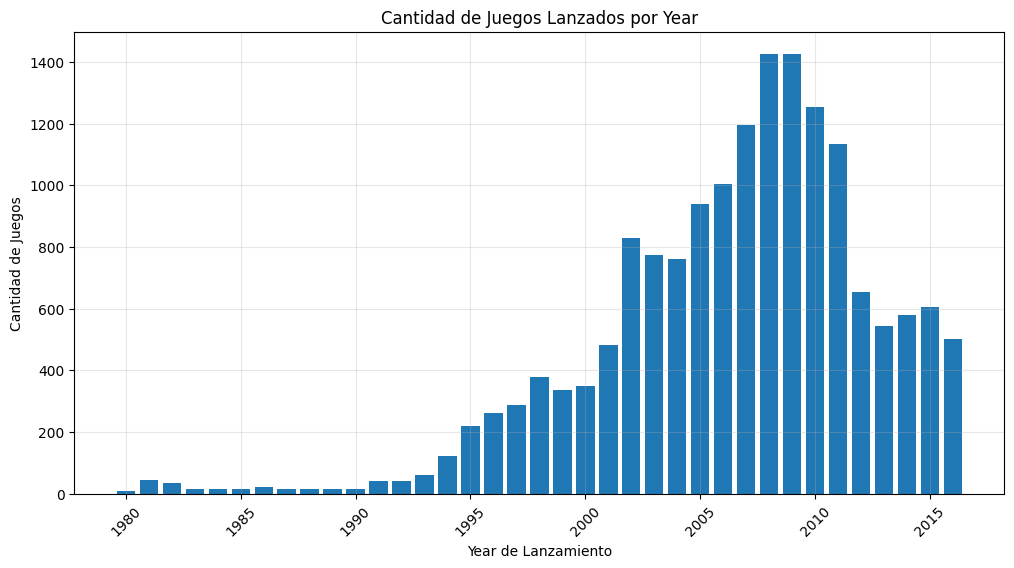

In [ ]:
# ver la distribucion de los datos de juegos por year release
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(games_per_year.index, games_per_year.values)
plt.title('Cantidad de Juegos Lanzados por Year')
plt.xlabel('Year de Lanzamiento')
plt.ylabel('Cantidad de Juegos')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

Si son significativos, a medida que avanzan los yearsdesde 1980 hasta 1990 fueron bajos los lanzamientos pero luego comienza a aumentar sginificativamente, hasta alcanzar un aumento sisgnificativo entre los years 2006 y 2011 con 4 cifras significativas o ms de 1000 juegos. Luego ocurre un descenso en los lanzamientos alrededor de 600 juegos.

In [ ]:
#Variacion de ventas por plataforma

sales_per_platform= df.groupby('platform')['total_sales'].sum()
print(sales_per_platform.sort_values(ascending=False))
top_platforms=sales_per_platform.sort_values(ascending=False).head(6).index.tolist()
print(top_platforms)



platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       30.77
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64
['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']


In [ ]:
#filtrar usando la lista creada top_platforms el dataframe para por year
top_platforms_years_fil_df=df[df['platform'].isin(top_platforms)]

#agrupar por year usando el filtro anterior y contat las platforms
top_platforms_years=top_platforms_years_fil_df.groupby('year_of_release')['platform'].value_counts()
print(top_platforms_years)

year_of_release  platform
1985             DS            1
1994             PS           17
1995             PS           99
1996             PS          164
1997             PS          188
                            ... 
2015             X360         35
                 Wii           4
2016             PS3          38
                 X360         13
                 Wii           1
Name: platform, Length: 67, dtype: int64


In [ ]:
#crear distribucion de ventas por year de las top 6 plataformas encontradas
ventas_top_platforms_year=top_platforms_years_fil_df.groupby('year_of_release')['total_sales'].sum()
print("Distribución de ventas por año (top 6 plataformas):")
print(ventas_top_platforms_year.sort_index())

Distribución de ventas por año (top 6 plataformas):
year_of_release
1985      0.02
1994      6.03
1995     35.96
1996     94.70
1997    136.17
1998    169.49
1999    144.53
2000    135.54
2001    202.02
2002    212.05
2003    186.38
2004    229.08
2005    299.05
2006    432.96
2007    544.30
2008    624.31
2009    604.13
2010    530.81
2011    386.90
2012    239.82
2013    211.96
2014     86.25
2015     29.92
2016      5.30
Name: total_sales, dtype: float64


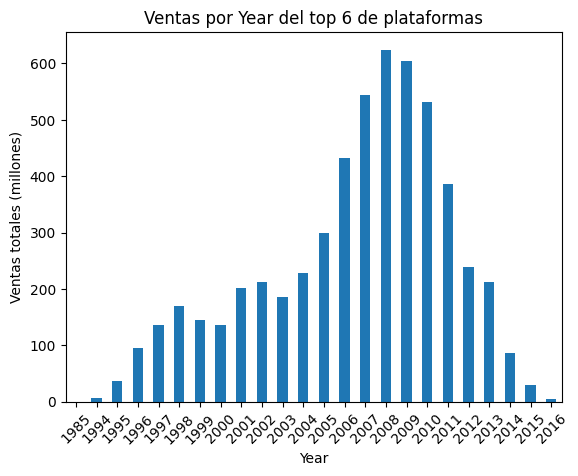

In [ ]:

#grafico de la distribucion
ventas_top_platforms_year.plot(kind='bar')
plt.title('Ventas por Year del top 6 de plataformas')
plt.xlabel('Year')
plt.ylabel('Ventas totales (millones)')
plt.xticks(rotation=45)
plt.show()


Ventas por año y plataforma:
platform             DS      PS     PS2     PS3     Wii    X360
year_of_release                                                
1985               0.02    0.00    0.00    0.00    0.00    0.00
1994               0.00    6.03    0.00    0.00    0.00    0.00
1995               0.00   35.96    0.00    0.00    0.00    0.00
1996               0.00   94.70    0.00    0.00    0.00    0.00
1997               0.00  136.17    0.00    0.00    0.00    0.00
1998               0.00  169.49    0.00    0.00    0.00    0.00
1999               0.00  144.53    0.00    0.00    0.00    0.00
2000               0.00   96.37   39.17    0.00    0.00    0.00
2001               0.00   35.59  166.43    0.00    0.00    0.00
2002               0.00    6.67  205.38    0.00    0.00    0.00
2003               0.00    2.07  184.31    0.00    0.00    0.00
2004              17.27    0.00  211.81    0.00    0.00    0.00
2005             130.14    0.00  160.66    0.00    0.00    8.25
2006       

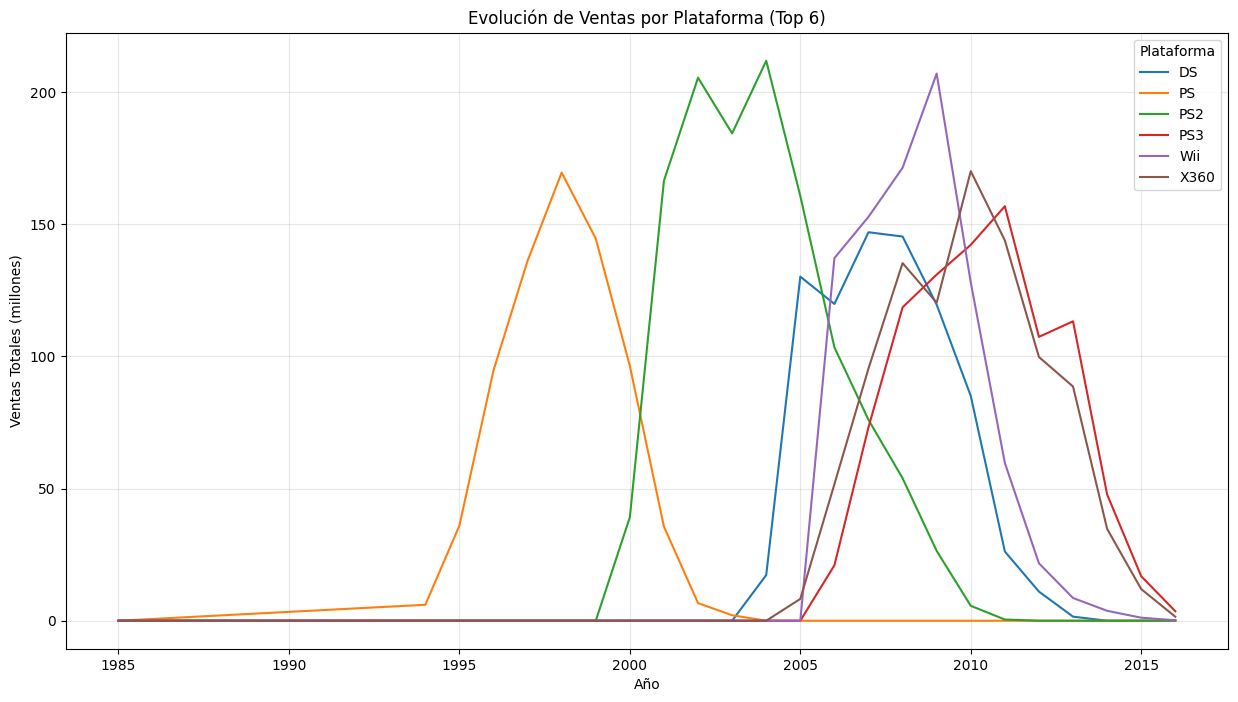

In [ ]:
# Crear tabla pivote: años en filas, plataformas en columnas
ventas_pivot = top_platforms_years_fil_df.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)
print("Ventas por año y plataforma:")
print(ventas_pivot)


# Líneas separadas para cada plataforma
ventas_pivot.plot(kind='line', figsize=(15,8))
plt.title('Evolución de Ventas por Plataforma (Top 6)')
plt.xlabel('Año')
plt.ylabel('Ventas Totales (millones)')
plt.legend(title='Plataforma')
plt.grid(True, alpha=0.3)
plt.show()




Se puede observar en los graficos que las plataformas pasan de moda y tienen tiempo de duracion en el mercado, es decir un ciclo productivo. Las plataformas que solian ser las mas vendidas eran PS que fue del 1994 hasta 2003 (9 years) , PS2 del 2000 al 2011 (11 years), y luego DS que estuvo productiva del 2004 al 2013 (9 years). El resto de las plataformas indican que estan en su periodo de salida del mercado porque han disminudi drasticamente las ventas, presentando el mismo comportamientos que las plataformas anteriores, es decir estan finalizando su ciclo en el mercado.

Tanto PS3 AL 2016 (10 years), Wii (10 years), X360 (11 years), se nota que ya estan por salir del mercado o estan en declive por su gran reduccion en ventas.

Las plataformas nuevas en aparecer salienron casi al mismo tiempo ocn un year de diferencia PS3 AL 2016 (10 years), Wii (10 years), X360 (11 years), pero entre las antiguar si hay una diferencia DS como la mas antigua del Mercado aparecio y desaperio en su year de lanzamiento 1985 y luego vuelve en el 2004 (2004-2013 = 9 años), algo tuvo que suceder a nivel de mercado o capacidad para que esto sucediera, a los 9 years aparece PS ( 1994-2003 = 9 años), 6 year despues aparece PS2 (2000-2011 = 11 años), Luego X360 (2005) WII y PS3 en el 2006 al mismo tiempo, aumentando la frecuencia de neuvas plataformas con el tiempo.

El ciclo de vida de las plataformas tops es 9 a 11 years. 
Estas plataformas estan declive: PS3, X360, Wii (ventas mínimas en 2016)
Estas plataformas DS,PS,PS2 ya no tienen ventas en el 2016, han sido desplazadas por nuevas plataformas. 


ESTUDIO PARA IDENTIFICAR EL MODELO PARA EL 2017
Observando los datos anteriores del top de ventas se puede identifica que estos platforms estan en declive o cierre de ciclo productivo en el mercado, por lo que no los utilizare para realizar una prediccion para el 2017. 

Mi plan es revisar los platforms que hay en los ultimos  3 years con respecto al 2016 dado el comportamiento en declive de las ventas de las plataformas y tomando encuenta los ciclos de vid, mejor tomar las plataformas mas recientes para la prediccion.

In [ ]:
# Agrupar nuevamente el dataframe con todas las platformas para poder compararlas todas

ventas_pivot_all_platforms = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)
print("Ventas por año en todas las plataformas")
print(ventas_pivot_all_platforms)

#Mostrar distribucion en el tiempo de todas las plataformas desde el 2013 al 2016
ventas_all_platform_2013_2016= ventas_pivot_all_platforms[ventas_pivot_all_platforms.index>2012]
print(ventas_all_platform_2013_2016)

# Eliminar plataformas que tienen solo ceros en el período 2013-2016
ventas_filtradas = ventas_all_platform_2013_2016.loc[:, (ventas_all_platform_2013_2016 != 0).any()]
print("Plataformas con ventas en el período:")
print(ventas_filtradas.columns.tolist())

# Filtrar solo las plataformas que tienen ventas > 0 en algún año del período
plataformas_activas = ventas_filtradas.loc[:, (ventas_filtradas > 0).any()].columns.tolist()
print("Plataformas con ventas reales:", plataformas_activas)

# Crear el DataFrame solo con estas plataformas
ventas_activas = ventas_filtradas[plataformas_activas]
print(ventas_activas)

Ventas por año en todas las plataformas
platform          2600   3DO    3DS    DC      DS     GB    GBA     GC    GEN  \
year_of_release                                                                 
1980             11.38  0.00   0.00  0.00    0.00   0.00   0.00   0.00   0.00   
1981             35.68  0.00   0.00  0.00    0.00   0.00   0.00   0.00   0.00   
1982             28.88  0.00   0.00  0.00    0.00   0.00   0.00   0.00   0.00   
1983              5.84  0.00   0.00  0.00    0.00   0.00   0.00   0.00   0.00   
1984              0.27  0.00   0.00  0.00    0.00   0.00   0.00   0.00   0.00   
1985              0.45  0.00   0.00  0.00    0.02   0.00   0.00   0.00   0.00   
1986              0.67  0.00   0.00  0.00    0.00   0.00   0.00   0.00   0.00   
1987              1.94  0.00   0.00  0.00    0.00   0.00   0.00   0.00   0.00   
1988              0.74  0.00   0.00  0.00    0.00   1.43   0.00   0.00   0.00   
1989              0.63  0.00   0.00  0.00    0.00  64.97   0.00   0.0

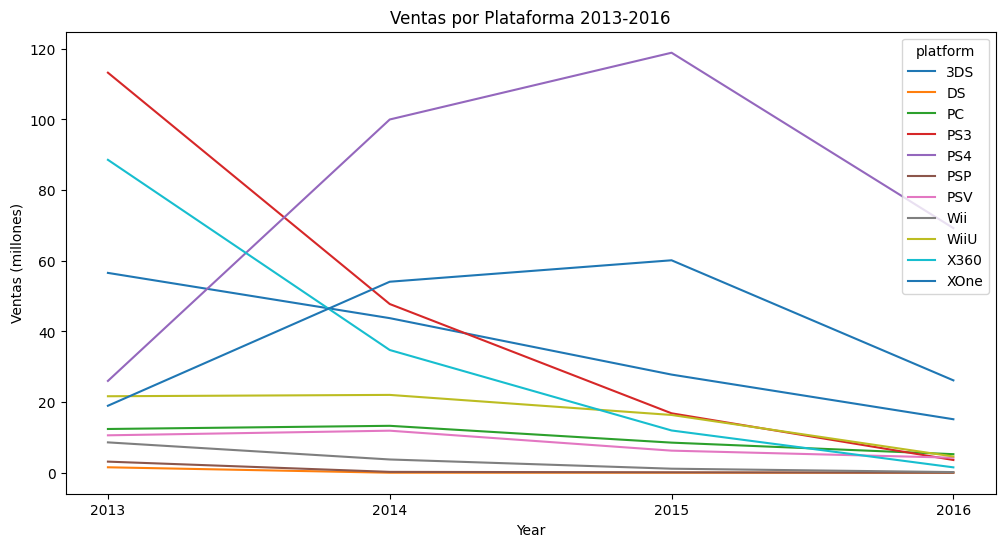

In [ ]:
# Líneas separadas para cada plataforma

# Gráfico de las plataformas activas
ventas_activas.plot(figsize=(12, 6))
plt.title('Ventas por Plataforma 2013-2016')
plt.xlabel('Year')
plt.xticks([2013, 2014, 2015, 2016])
plt.ylabel('Ventas (millones)')
plt.show()



Aqui se puede observar que las plataformas que tendran mayores ventas para el 2017 son PS4 y XONE (pico en 2015, bajan en 2016), sin embargo todas las plataforma ya van en declive, lo que indica que le quedaran pocos years para generar ingresos, seguro por nuevas plataformas emergentes o cambios en el mercado.

In [ ]:
#ventas globales de todos los juegos, deglosados por plataforma

ventas_globales_plat=df.groupby(['platform'])['total_sales'].sum().sort_values(ascending=False)
print("Top 10 plataformas por ventas totales:")
print(ventas_globales_plat.head(10))


Top 10 plataformas por ventas totales:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


Las plataformas lideres en ventas son las siguentes 
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52

<Figure size 1500x800 with 0 Axes>

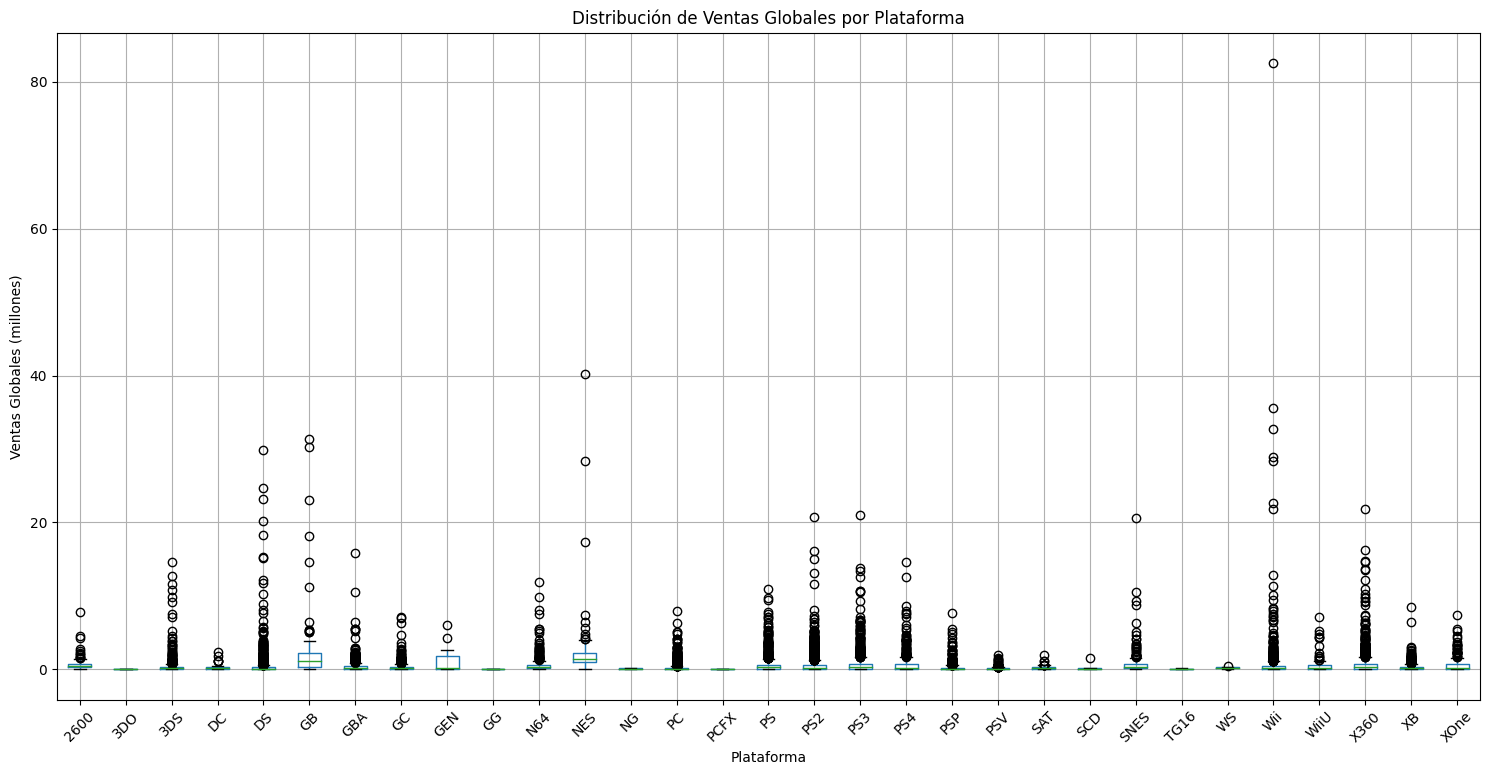

Estadísticas descriptivas por plataforma:
           count  mean   std   min   25%   50%   75%    max
platform                                                   
2600       133.0  0.73  0.92  0.07  0.30  0.46  0.78   7.81
3DO          3.0  0.03  0.02  0.02  0.02  0.02  0.04   0.06
3DS        520.0  0.50  1.43  0.01  0.05  0.12  0.33  14.60
DC          52.0  0.31  0.47  0.02  0.08  0.14  0.30   2.41
DS        2151.0  0.37  1.43  0.01  0.05  0.11  0.27  29.80
GB          98.0  2.61  5.37  0.06  0.30  1.16  2.16  31.38
GBA        822.0  0.39  0.90  0.01  0.05  0.16  0.39  15.84
GC         556.0  0.36  0.69  0.01  0.06  0.15  0.35   7.06
GEN         29.0  1.06  1.47  0.03  0.07  0.15  1.76   6.02
GG           1.0  0.04   NaN  0.04  0.04  0.04  0.04   0.04
N64        319.0  0.69  1.32  0.01  0.14  0.27  0.60  11.90
NES         98.0  2.56  5.11  0.06  1.00  1.38  2.22  40.24
NG          12.0  0.12  0.08  0.02  0.06  0.10  0.20   0.25
PC         974.0  0.27  0.68  0.01  0.02  0.05  0.17   8.0

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el boxplot
plt.figure(figsize=(15, 8))
df.boxplot(column='total_sales', by='platform', figsize=(15, 8), showfliers=False)
plt.title('Distribución de Ventas Globales por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones)')
plt.xticks(rotation=45)
plt.suptitle('')  # Eliminar el título automático
plt.tight_layout()
plt.show()

# Estadísticas descriptivas por plataforma
stats_by_platform = df.groupby('platform')['total_sales'].describe()
print("Estadísticas descriptivas por plataforma:")
print(stats_by_platform.round(2))

# Cálculos de desviación estándar y varianza para ventas totales
print("=== ANÁLISIS DE VARIABILIDAD DE VENTAS ===")
print()

# Desviación estándar y varianza general
print("Estadísticas generales de ventas totales:")
print(f"Desviación estándar: {df['total_sales'].std():.3f} millones")
print(f"Varianza: {df['total_sales'].var():.3f}")
print()

# Por plataforma (top 8)
top_8_platforms = ventas_globales_plat.head(8).index.tolist()
print("Top 8 plataformas:", top_8_platforms)

print("Desviación estándar y varianza por plataforma (Top 8):")
for platform in top_8_platforms:
    platform_data = df[df['platform'] == platform]['total_sales']
    std_dev = platform_data.std()
    variance = platform_data.var()
    print(f"{platform}: SD = {std_dev:.3f}, VAR = {variance:.3f}")

<Figure size 1200x600 with 0 Axes>

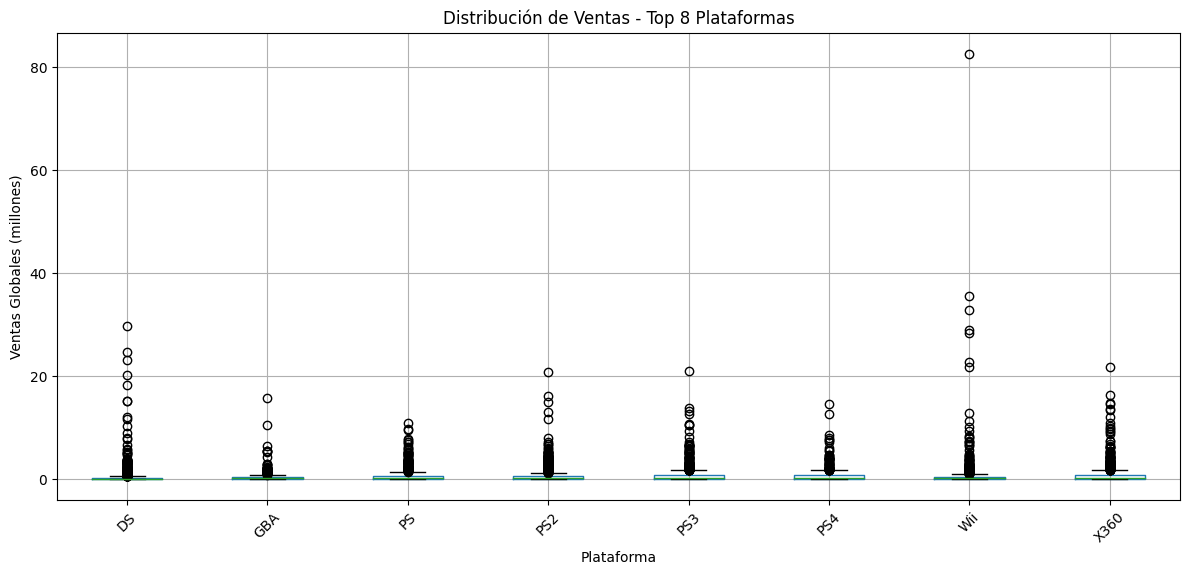

In [ ]:
# Solo las top 8 plataformas
top_8_platforms = ventas_globales_plat.head(8).index
df_top8 = df[df['platform'].isin(top_8_platforms)]

plt.figure(figsize=(12, 6))
df_top8.boxplot(column='total_sales', by='platform', figsize=(12, 6), showfliers=False)
plt.title('Distribución de Ventas - Top 8 Plataformas')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones)')
plt.xticks(rotation=45)
plt.suptitle('')
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

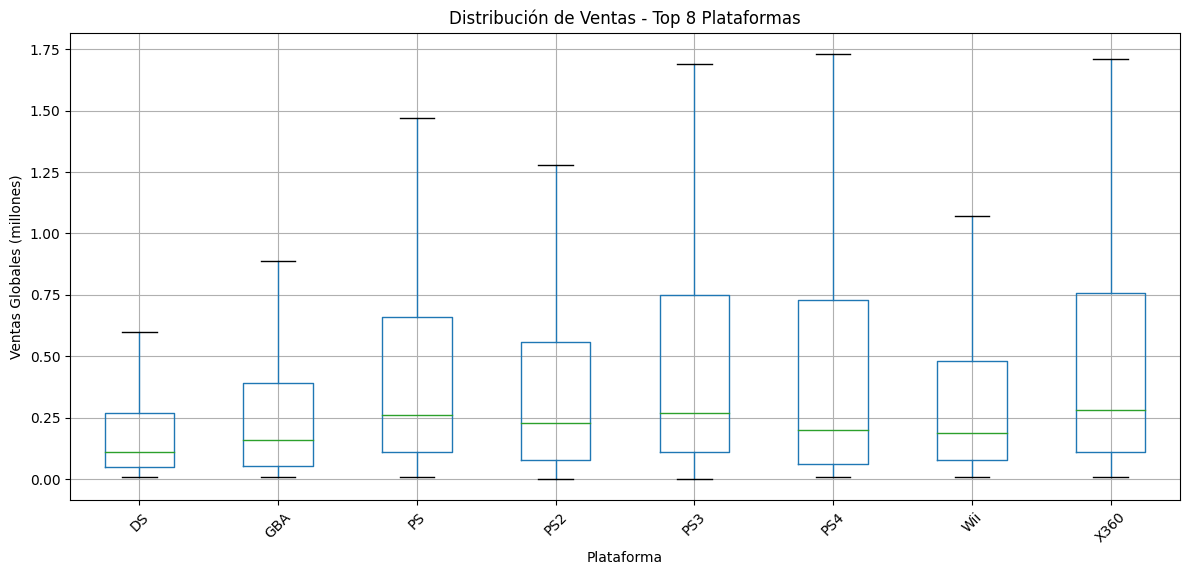

In [ ]:
plt.figure(figsize=(12, 6))
df_top8.boxplot(column='total_sales', by='platform', figsize=(12, 6), showfliers = False) # <- Nuevo parametro aquí
plt.title('Distribución de Ventas - Top 8 Plataformas')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones)')
plt.xticks(rotation=45)
plt.suptitle('')
plt.tight_layout()
plt.show()


Son significativas las diferencias en las ventas se puede observar que hay mucha variabilidad en los datos, casi todos los datos tienen valores por encima de los valores maximos y minimos o valores atipicos, por ejemplo wii
tuvo ventas altisimas, luego DS y x360 pero estos ultimos. El resto tiene atipicos pero no tan fuera de la caja, la mayoria de los juegos no han repuntado de esta forma


VERIFICAR QUE ES MAS RENTABLE APOSTAR A JUEGOS BLOCKBUSTER O MUCHOS JEUGOS POCAS VENTAS

In [ ]:
cantidad_games_platform=df.groupby('platform')['name'].count().sort_values(ascending=False)
ingresos_games_platform=df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Crear un DataFrame para comparar
comparacion = pd.DataFrame({
    'total_sales': ingresos_games_platform,
    'num_games': cantidad_games_platform
})
comparacion['sales_per_game'] = comparacion['total_sales'] / comparacion['num_games']
print(comparacion)

# Por eficiencia (ventas por juego, de mayor a menor)
por_eficiencia = comparacion.sort_values('sales_per_game', ascending=False)
print(por_eficiencia)

          total_sales  num_games  sales_per_game
platform                                        
2600            96.98        133        0.729173
3DO              0.10          3        0.033333
3DS            259.00        520        0.498077
DC              15.95         52        0.306731
DS             806.12       2151        0.374765
GB             255.46         98        2.606735
GBA            317.85        822        0.386679
GC             198.93        556        0.357788
GEN             30.77         29        1.061034
GG               0.04          1        0.040000
N64            218.68        319        0.685517
NES            251.05         98        2.561735
NG               1.44         12        0.120000
PC             259.52        974        0.266448
PCFX             0.03          1        0.030000
PS             730.86       1197        0.610576
PS2           1255.77       2161        0.581106
PS3            939.65       1331        0.705973
PS4            314.1

Con los datos anteriores se puede observar que es mejor a apsotar a juegos blockbuster que generan mayor ganancia que sacar muchos juegos y obtener ganancias pero menos, lo que implica mas esfuerzo por menos ingresos. Tambiense observa que sacar muy pocos juegos no genera mucho ingreso, estas plataformas son los que tienen mayores retornos
GB             255.46         98        2.606735
NES            251.05         98        2.561735
GEN             30.77         29        1.061034

DS: 2151 juegos, solo 0.37M por juego → mucho esfuerzo, poco retorno
GB/NES: 98 juegos, 2.6M por juego → esfuerzo moderado, alto retorno

PS4 y XONE podrian apuntar a una cantidad moderada de jeugos de calidad para obtener buen retorno de ganancias, ya que son las que tienen aun chiclo de vida activo a pesar de su declive.

REVISION DE RESEÑAS DE USUARIOS Y PROFESIONALES. COMO AFECTAN LAS VENTNAS DE UNA PLATAFORMA

In [ ]:
print(df.head(5))

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score user_score   rating  \
0     28.96      3.77         8.45          76.0          8        E   
1      3.58      6.81         0.77           NaN        NaN  Unrated   
2     12.76      3.79         3.29          82.0        8.3        E   
3     10.93      3.28         2.95          80.0          8        E   
4      8.89     10.22         1.00           NaN        NaN  Unrated   

            name_normalized             name_stripped  \
0                wii sp

In [ ]:
platforma_PS4=df[df['platform']=='PS4']
print(platforma_PS4)

print("Valores únicos en user_score para PS4:")
print(platforma_PS4['user_score'].value_counts())

#  limpiar user_score
platforma_PS4_clean = platforma_PS4.copy()
# Convertir 'tbd' a NaN y luego a float


platforma_PS4_clean['user_score_numeric'] = pd.to_numeric(
    platforma_PS4_clean['user_score'].replace('tbd', None), 
    errors='coerce'
)



                                 name platform  year_of_release         genre  \
31          Call of Duty: Black Ops 3      PS4             2015       Shooter   
42                 Grand Theft Auto V      PS4             2014        Action   
77                            FIFA 16      PS4             2015        Sports   
87       Star Wars Battlefront (2015)      PS4             2015       Shooter   
92     Call of Duty: Advanced Warfare      PS4             2014       Shooter   
...                               ...      ...              ...           ...   
16500                     Root Letter      PS4             2016     Adventure   
16503               Shin Hayarigami 2      PS4             2016     Adventure   
16526                      Dungeons 2      PS4             2016  Role-Playing   
16530         Carmageddon: Max Damage      PS4             2016        Action   
16585   Farming 2017 - The Simulation      PS4             2016    Simulation   

       na_sales  eu_sales  

In [ ]:
# limpiar user_score (tbd)


platforma_PS4_clean = platforma_PS4.copy()
# Convertir 'tbd' a NaN y luego a float
platforma_PS4_clean['user_score_numeric'] = pd.to_numeric(
    platforma_PS4_clean['user_score'].replace('tbd', None), 
    errors='coerce'

)
print(platforma_PS4_clean.corr())


                    year_of_release  na_sales  eu_sales  jp_sales  \
year_of_release            1.000000 -0.248961 -0.208306 -0.060993   
na_sales                  -0.248961  1.000000  0.785362  0.472981   
eu_sales                  -0.208306  0.785362  1.000000  0.464563   
jp_sales                  -0.060993  0.472981  0.464563  1.000000   
other_sales               -0.234796  0.944259  0.944698  0.496467   
critic_score              -0.021142  0.415008  0.346720  0.322358   
total_sales               -0.235032  0.928160  0.958157  0.527129   
user_score_numeric         0.152418 -0.022435 -0.050233  0.169159   

                    other_sales  critic_score  total_sales  user_score_numeric  
year_of_release       -0.234796     -0.021142    -0.235032            0.152418  
na_sales               0.944259      0.415008     0.928160           -0.022435  
eu_sales               0.944698      0.346720     0.958157           -0.050233  
jp_sales               0.496467      0.322358     0.52

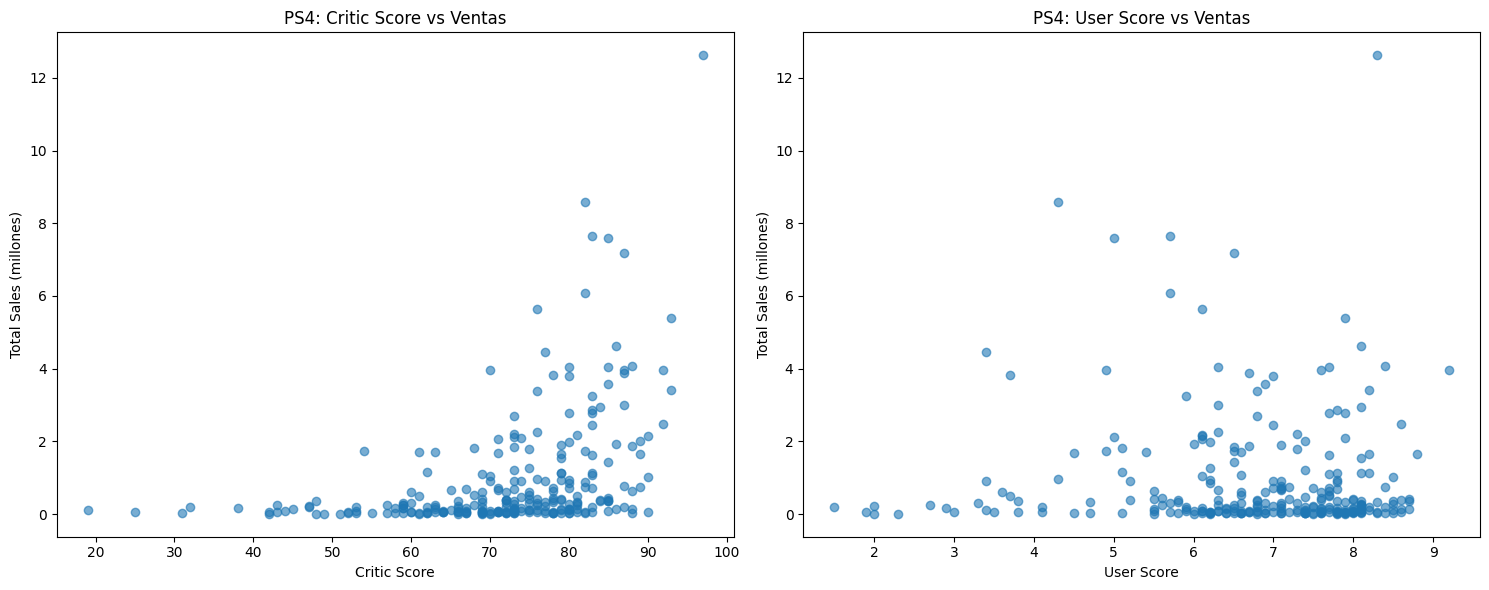

In [ ]:
# Crear subplots para ambas reseñas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Ventas
ax1.scatter(platforma_PS4_clean['critic_score'], platforma_PS4_clean['total_sales'], alpha=0.6)
ax1.set_xlabel('Critic Score')
ax1.set_ylabel('Total Sales (millones)')
ax1.set_title('PS4: Critic Score vs Ventas')

# Gráfico 2: User Score vs Ventas  
ax2.scatter(platforma_PS4_clean['user_score_numeric'], platforma_PS4_clean['total_sales'], alpha=0.6)
ax2.set_xlabel('User Score')
ax2.set_ylabel('Total Sales (millones)')
ax2.set_title('PS4: User Score vs Ventas')

plt.tight_layout()
plt.show()

Se puede observar alta variabilidad entre las criticas profesionales y de usuarios, si embargo se observa que la correlacion es diferente entre profesional y los usuarios, positiva para critic_score o profesional ( 0.406568 ) y negativa casi cero para los user ( -0.033475). La correlacion tan variable de los user_score hace ver que no predice el comportamiento de la ventas mientras que los  profesiones si dan mejores resultados, a mayor puntuacion se esperan mayores ventas. Tambien se puede observar que hay muchos valores atipicos en user score a diferencia de critic score

In [ ]:
# Filtrar juegos con ventas muy bajas (por ejemplo, menos de 0.01 millones)
juegos_sin_ventas = df[df['total_sales'] <= 0.01]
print(f"Juegos con ventas ≤ 0.01 millones: {len(juegos_sin_ventas)}")

# Contar cuántos tienen user_score válido (no NaN y no 'tbd')
juegos_sin_ventas_con_user_score = juegos_sin_ventas[
    (juegos_sin_ventas['user_score'].notna()) & 
    (juegos_sin_ventas['user_score'] != 'tbd')
]
print(f"Juegos sin ventas que tienen user_score: {len(juegos_sin_ventas_con_user_score)}")

# Analizar las puntuaciones de estos juegos sin ventas
print("Puntuaciones de usuarios en juegos con ventas ≤ 0.01:")
print(juegos_sin_ventas_con_user_score['user_score'].value_counts().head(10))

# Comparar con juegos exitosos
juegos_exitosos = df[df['total_sales'] > 1.0]  # Más de 1 millón en ventas
print(f"\nJuegos exitosos (>1M ventas): {len(juegos_exitosos)}")

Juegos con ventas ≤ 0.01 millones: 799
Juegos sin ventas que tienen user_score: 209
Puntuaciones de usuarios en juegos con ventas ≤ 0.01:
8      12
7.5    11
8.3    10
7.6     9
7.9     9
8.2     8
6.8     8
7.1     7
7.3     7
8.8     6
Name: user_score, dtype: int64

Juegos exitosos (>1M ventas): 2061


In [ ]:
#Revisar los mismo juegos en otra plataforma como XONE
juegos_ps4=platforma_PS4_clean['name']
platforma_xone = df[df['platform'] == 'XOne']
juegos_comunes = df[df['name'].isin(juegos_ps4) & (df['platform'] == 'XOne')]
print(juegos_comunes)

# limpiar user_score (tbd)

platforma_xone_clean = juegos_comunes.copy()
# Convertir 'tbd' a NaN y luego a float
platforma_xone_clean['user_score_numeric'] = pd.to_numeric(
    platforma_xone_clean['user_score'].replace('tbd', None), 
    errors='coerce'
)
print(platforma_xone_clean.corr())

                                                name platform  \
99                         Call of Duty: Black Ops 3     XOne   
165                               Grand Theft Auto V     XOne   
179                   Call of Duty: Advanced Warfare     XOne   
270                                        Fallout 4     XOne   
342                     Star Wars Battlefront (2015)     XOne   
...                                              ...      ...   
16630                       Sébastien Loeb Rally Evo     XOne   
16643                              Rugby Challenge 3     XOne   
16645                                         ZombiU     XOne   
16660                               Prison Architect     XOne   
16672  Metal Gear Solid V: The Definitive Experience     XOne   

       year_of_release         genre  na_sales  eu_sales  jp_sales  \
99                2015       Shooter      4.59      2.11      0.01   
165               2014        Action      2.81      2.19      0.00   
179      

Se observa que en la plataforma XONE para los mismos juegos ocurre el mismo patron que en PS4. 
Critic Score: Correlación positiva moderada con las ventas totales
User Score: Correlación casi nula o ligeramente negativa con las ventas
Esto implica que a lo mejor los criticos estan aliados con las plataformas

REVISAR LAS VENTAS DE JUEGOS POR GENERO

In [ ]:
juegos_genero=df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print(juegos_genero)

genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Name: total_sales, dtype: float64


Los generos que mas ganancias generan son: 
1.Accion
2.Sports
3.Shooter
4.Role-Playing
5.Platform

Se puede observar en que los juegos con mas ventas tienen que ver con accion, movimiento, que generen emociones fuertes

Los jeugos de mas bajas ventas son los generos siguientes:
Puzzle           242.57
Adventure        237.59
Strategy         174.23

Esto indica que los juegos que requieren pensar o analizar no venden tanto como los mas institivos 

PASO 4. PERFIL DE USUARIO POR CADA REGION (NA.UE, JP)
4.1. Determinar las 5 Plataformas principales
4.2. Los 5 generos principales y diferencias
4.3 Si calificacion ESRB afectan las ventas en las regiones

4.1 Determinar las 5 Plataformas principales para las distintas regiones

In [ ]:
# Crear DataFrame con todas las plataformas y sus ventas por región
print('platform_region_sales')
platform_region_sales_na=df.groupby('platform')['na_sales'].sum()
platform_region_sales_na["%mercado_na"]=(platform_region_sales_na/platform_region_sales_na.sum())*100
top_5_platformas_na=platform_region_sales_na["%mercado_na"].sort_values(ascending=False).head(5)
print("Top 5 plataformas en NA:")
print(top_5_platformas_na)

platform_region_sales_eu = df.groupby('platform')['eu_sales'].sum()
platform_region_sales_eu["%mercado_eu"] = (platform_region_sales_eu/platform_region_sales_eu.sum())*100
top_5_platformas_eu = platform_region_sales_eu["%mercado_eu"].sort_values(ascending=False).head(5)
print("Top 5 plataformas en EU:")
print(top_5_platformas_eu)

platform_region_sales_jp = df.groupby('platform')['jp_sales'].sum()
platform_region_sales_jp["%mercado_jp"] = (platform_region_sales_jp/platform_region_sales_jp.sum())*100
top_5_platformas_jp = platform_region_sales_jp["%mercado_jp"].sort_values(ascending=False).head(5)
print("Top 5 plataformas en JP:")
print(top_5_platformas_jp)

platform_region_sales
Top 5 plataformas en NA:
platform
X360    13.685191
PS2     13.262008
Wii     11.287153
PS3      8.938181
DS       8.686270
Name: na_sales, dtype: float64
Top 5 plataformas en EU:
platform
PS2     13.993244
PS3     13.622060
X360    11.166880
Wii     10.814255
PS       8.809859
Name: eu_sales, dtype: float64
Top 5 plataformas en JP:
platform
DS      13.532762
PS      10.777188
PS2     10.729399
SNES     8.983559
3DS      7.759544
Name: jp_sales, dtype: float64


In [ ]:
#Unir con concat las series creadas para poder analizarlas en un grafica
resultado = pd.concat([top_5_platformas_na,top_5_platformas_eu, top_5_platformas_jp], axis=1)
resultado.columns = ['NA', 'EU', 'JP']
print(resultado)
print(type(resultado))

                 NA         EU         JP
platform                                 
X360      13.685191  11.166880        NaN
PS2       13.262008  13.993244  10.729399
Wii       11.287153  10.814255        NaN
PS3        8.938181  13.622060        NaN
DS         8.686270        NaN  13.532762
PS              NaN   8.809859  10.777188
SNES            NaN        NaN   8.983559
3DS             NaN        NaN   7.759544
<class 'pandas.core.frame.DataFrame'>


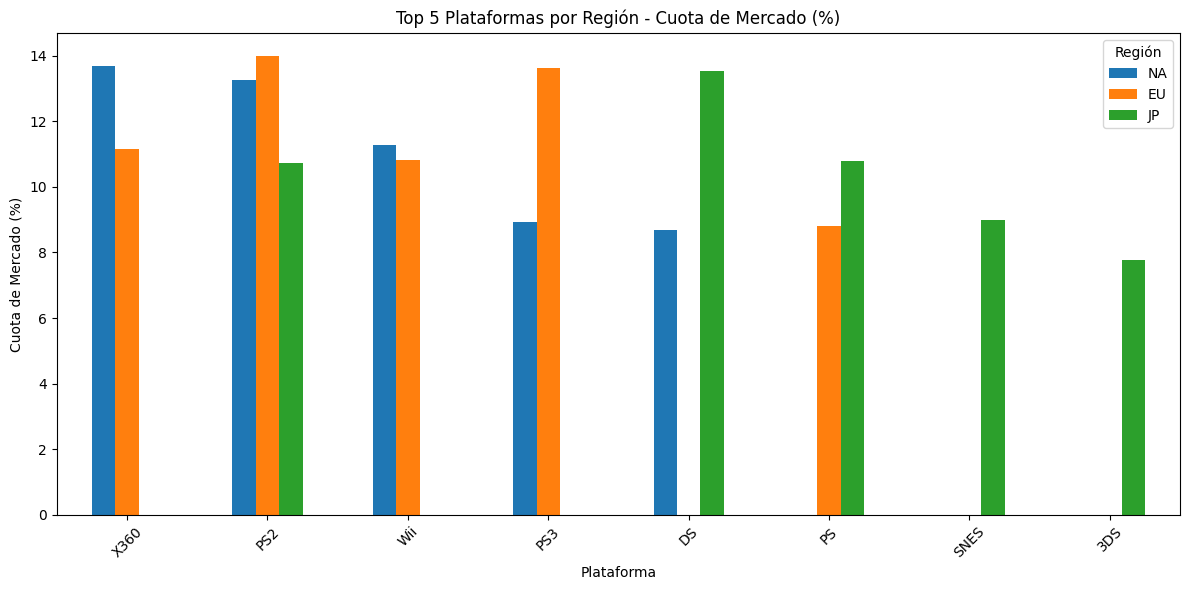

In [ ]:
#Graficar la tabla unida resultado
import matplotlib.pyplot as plt

# Crear el gráfico de barras agrupadas
resultado.plot(kind='bar', figsize=(12, 6))
plt.title('Top 5 Plataformas por Región - Cuota de Mercado (%)')
plt.xlabel('Plataforma')
plt.ylabel('Cuota de Mercado (%)')
plt.legend(title='Región')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Como resultado de la visualizacion de las 5 platformas top en los mercados EU,NA y JP, se puede evidenciar que para las plataformas X360, PS2, Wii tanto en NA como en EU son lideres con partes del mercado muy similares. Japon JP, tiene un comportamiento muy distinto teniedno como lider DSue solo aparece en NA  luego PS yPS2 como en las otras regiones y tiene SNES y 3DS que no lo tienen en sus mercados las regiones EU y NA.

Cinco géneros principales (Tomando los mismas 5 plataformas encontradas con el fin de ver las preferencias)

In [ ]:

# Obtener los nombres de las plataformas (índices) en lugar de los valores
top_platforms_na = top_5_platformas_na.index.tolist()
print("Plataformas top NA:", top_platforms_na)

# Filtrar juegos que pertenecen a estas plataformas
juegos_top_platforms_na = df[df['platform'].isin(top_platforms_na)]

# Analizar géneros en estas plataformas top
generos_en_top_platforms_na = juegos_top_platforms_na.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
print("Géneros más vendidos en plataformas top NA:")
print(generos_en_top_platforms_na.head(5))


top_platforms_eu = top_5_platformas_eu.index.tolist()
print("Plataformas top EU:", top_platforms_eu)

# Filtrar juegos que pertenecen a estas plataformas
juegos_top_platforms_eu = df[df['platform'].isin(top_platforms_eu)]

# Analizar géneros en estas plataformas top
generos_en_top_platforms_eu = juegos_top_platforms_eu.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
print("Géneros más vendidos en plataformas top EU:")
print(generos_en_top_platforms_eu.head(5))

top_platforms_jp = top_5_platformas_jp.index.tolist()
print("Plataformas top JP:", top_platforms_jp)

# Filtrar juegos que pertenecen a estas plataformas
juegos_top_platforms_jp = df[df['platform'].isin(top_platforms_jp)]

# Analizar géneros en estas plataformas top
generos_en_top_platforms_jp = juegos_top_platforms_jp.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
print("Géneros más vendidos en plataformas top JP:")
print(generos_en_top_platforms_jp.head(5))


Plataformas top NA: ['X360', 'PS2', 'Wii', 'PS3', 'DS']
Géneros más vendidos en plataformas top NA:
genre
Action     524.02
Sports     450.25
Shooter    338.75
Misc       299.72
Racing     184.20
Name: na_sales, dtype: float64
Plataformas top EU: ['PS2', 'PS3', 'X360', 'Wii', 'PS']
Géneros más vendidos en plataformas top EU:
genre
Action     327.69
Sports     278.48
Shooter    201.19
Racing     160.02
Misc       143.31
Name: eu_sales, dtype: float64
Plataformas top JP: ['DS', 'PS', 'PS2', 'SNES', '3DS']
Géneros más vendidos en plataformas top JP:
genre
Role-Playing    205.26
Action           77.13
Sports           66.26
Misc             62.16
Simulation       48.85
Name: jp_sales, dtype: float64


Con los resultados obtenido se puede observar que las regiones NA y EU tienen como preferencia los juegos de accion, sport y shooter en el mismo orden a diferencia que en JP los juegos prefieredios con muchisima difernecia son Role-playing, luego si action y sports, tienen un categoria que no tiene EU y  NA, que es simulation en 5 lugar

CLASIFICACIONES ESRB (afectan a las ventas en regiones individuales?).

In [ ]:

rating_ventas_na=df.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
rating_ventas_eu=df.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
rating_ventas_jp=df.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

print("Ventas por clasificación ESRB - NA:")
print(rating_ventas_na)
print("\nVentas por clasificación ESRB - EU:")
print(rating_ventas_eu)
print("\nVentas por clasificación ESRB - JP:")
print(rating_ventas_jp)

# Porcentajes por región
rating_porcentaje_na = (rating_ventas_na / rating_ventas_na.sum() * 100).round(2)
print("Porcentajes NA:")
print(rating_porcentaje_na)

rating_porcentaje_eu = (rating_ventas_eu / rating_ventas_eu.sum() * 100).round(2)
print("Porcentajes EU:")
print(rating_porcentaje_eu)

rating_porcentaje_jp = (rating_ventas_jp / rating_ventas_jp.sum() * 100).round(2)
print("Porcentajes JP:")
print(rating_porcentaje_jp)

Ventas por clasificación ESRB - NA:
rating
E          1292.99
Unrated    1242.46
T           759.75
M           748.48
E10+        353.32
K-A           2.56
EC            1.53
AO            1.26
RP            0.00
Name: na_sales, dtype: float64

Ventas por clasificación ESRB - EU:
rating
E          710.25
Unrated    613.83
M          483.97
T          427.03
E10+       188.52
AO           0.61
K-A          0.27
EC           0.11
RP           0.08
Name: eu_sales, dtype: float64

Ventas por clasificación ESRB - JP:
rating
Unrated    841.96
E          198.11
T          151.40
M           64.24
E10+        40.20
K-A          1.46
AO           0.00
EC           0.00
RP           0.00
Name: jp_sales, dtype: float64
Porcentajes NA:
rating
E          29.37
Unrated    28.22
T          17.26
M          17.00
E10+        8.03
K-A         0.06
EC          0.03
AO          0.03
RP          0.00
Name: na_sales, dtype: float64
Porcentajes EU:
rating
E          29.29
Unrated    25.32
M          19.96


Se puede observar que en NA y EU dominan la clasificacion E, y luego se tiene datos sin calificar, en JP la mayoria esta sin clasificacion y luego domina E. Estos rating quiza no aportan mucha informacion dado que sin rating hay un gran porcentaje de datos.

In [ ]:

# Juegos con ventas > 0 en NA
year_region_na = df[df['na_sales'] > 0].groupby('year_of_release').size()
print("Juegos vendidos en NA por año:")
print(year_region_na)



# Juegos con ventas > 0 en EU
year_region_eu = df[df['eu_sales'] > 0].groupby('year_of_release').size()
print("Juegos vendidos en EU por año:")
print(year_region_eu)



# Juegos con ventas > 0 en JP
year_region_jp = df[df['jp_sales'] > 0].groupby('year_of_release').size()
print("Juegos vendidos en JP por año:")
print(year_region_jp)



Juegos vendidos en NA por año:
year_of_release
1980       9
1981      46
1982      36
1983      17
1984      10
1985       9
1986      14
1987      15
1988      12
1989      14
1990      13
1991      14
1992      22
1993      17
1994      31
1995      84
1996     164
1997     205
1998     286
1999     270
2000     273
2001     411
2002     742
2003     714
2004     686
2005     850
2006     718
2007     874
2008    1077
2009    1056
2010     874
2011     756
2012     368
2013     328
2014     377
2015     322
2016     282
dtype: int64
Juegos vendidos en EU por año:
year_of_release
1980      9
1981     46
1982     36
1983     16
1984     10
1985      9
1986     12
1987     10
1988     11
1989     13
1990     12
1991     14
1992     21
1993     16
1994     29
1995     81
1996    162
1997    206
1998    288
1999    266
2000    271
2001    415
2002    716
2003    697
2004    669
2005    741
2006    527
2007    593
2008    734
2009    793
2010    709
2011    736
2012    389
2013    355
2014

In [ ]:
# Ventas promedio por rating en cada región
ventas_promedio_rating = df.groupby('rating').agg({
    'na_sales': 'mean',
    'eu_sales': 'mean', 
    'jp_sales': 'mean'
}).round(3)

print(ventas_promedio_rating)

         na_sales  eu_sales  jp_sales
rating                               
AO          1.260     0.610     0.000
E           0.324     0.178     0.050
E10+        0.249     0.133     0.028
EC          0.191     0.014     0.000
K-A         0.853     0.090     0.487
M           0.479     0.310     0.041
RP          0.000     0.027     0.000
T           0.257     0.144     0.051
Unrated     0.184     0.091     0.124


Las ventas promedios confirman que las clasificaciones ESRB no afectan las ventas, dado que algunas clasificaciones tienen cero ventas y si estaban con un rating (Ejemplo: EC en JP y RP en NA y JP). Los juegos unrating si presentan ventas significativas  na_sales 0.184,  eu_sales 0.091, jp_sales 0.124. La implementacion de los rating se observa que fue implementada pautainamente y luego tuvo un declive. En conclusion no es informacion relevante para los analisis.

PASO 5.PRUEBA DE HIPOSTESIS

5.1 Clasificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas. 

In [ ]:

#limpiar user_score de tbd

df['user_score']=pd.to_numeric(df['user_score'].replace('tbd', None), 
    errors='coerce')
#columna de datos a analizar para comparar las medias de las calificaciones de las plataformas Xbox One y PC
xone_scores = df[(df['platform'] == 'XOne') & (df['user_score'].notna())]['user_score']
pc_scores = df[(df['platform'] == 'PC') & (df['user_score'].notna())]['user_score']

Hipotesis Nula : los promedios de las plataformas Xbox One y PC son las mismas.

In [ ]:
print("=== HIPÓTESIS 1: XBOX ONE vs PC ===")
print("H0: promedio XONE= proemdio PC (los promedios son iguales)")
print("H1: promedio XONE ≠ promedio PC (los promedios son diferentes)")
from scipy import stats as st
alpha=0.05
results=st.ttest_ind(xone_scores,pc_scores,equal_var=False)
if results.pvalue<alpha:
    print('Rechazamos la hipotesis nula, las medias si son diferentes')
else:
    print('No podemos rechazar la hipotesis, no hay evidencia de diferencias entre las medias')


=== HIPÓTESIS 1: XBOX ONE vs PC ===
H0: promedio XONE= proemdio PC (los promedios son iguales)
H1: promedio XONE ≠ promedio PC (los promedios son diferentes)
Rechazamos la hipotesis nula, las medias si son diferentes


5.2 Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Hipotesis Alternativa: Los promedios de los usuarios para los géneros de Acción y Deportes son diferentes.

In [ ]:
#columna de datos a analizar para comparar las medias de las calificaciones de géneros de Acción y Deportes 

genre_action=df[(df['genre']=='Action')&(df['user_score'].notna())]['user_score']
genre_sports=df[(df['genre']=='Sports')&(df['user_score'].notna())]['user_score']

In [ ]:
print("=== HIPÓTESIS 2: GENERO ACTION vs SPORTS ===")
print("H0: promedio action = promedio sports (los promedios son iguales)")
print("H1: promedio action ≠ promedio sports (los promedios son diferentes)")
from scipy import stats as st
alpha=0.05
results=st.ttest_ind(genre_action,genre_sports,equal_var=False)
if results.pvalue<alpha:
    print('Rechazamos la hipotesis nula, las medias si son diferentes')
else:
    print('No podemos rechazar la hipotesis, no hay evidencia de diferencias entre las medias')


=== HIPÓTESIS 2: GENERO ACTION vs SPORTS ===
H0: promedio action = promedio sports (los promedios son iguales)
H1: promedio action ≠ promedio sports (los promedios son diferentes)
No podemos rechazar la hipotesis, no hay evidencia de diferencias entre las medias



PASO 6 CONCLUSION
CONCLUSIONES Y RECOMENDACIONES PARA 2017 
1. Plataformas objetivo: PS4 y XOne: Aun estas plataformas presentan las mayores ganancias dentro del mercado que aun estan activas y por estar en la vida util encontrada con referencia a otras plataformas que cumplieron su ciclo (9 a 11 years) todavia hay tiempo de hacer ajustes para obtener ganancias.
3. Géneros prioritarios: Action, Sports, Shooter: Los generos que implican emociones fuertes, violencia e instinto son los que mas gustan en los datos analizados. Sin embargo hay que tener en cuenta las regiones difieren un poco.
4. Estrategia regional:
- NA/EU: Enfocar en Action y Sports"
- JP: Priorizar Role-Playing
4. Calidad sobre cantidad: Apostar a blockbusters. Los datos demuestran que una cantidad moderada de juegos de calidad son los que generan mayores ganancias, a comparacion de sacar muchos juegos( 29 a 400 aproximandamente, ideal 98 juegos). Esto se basa en el análisis de plataformas exitosas que balancearon catálogo y calidad.
